# Ocean Alkalinity Enhancement (OAE) analysis

This notebook analyzes the Iceland3_MARBL_2024 OAE experiments in Hvalfjörður, focusing on how an imposed alkalinity (and associated carbon) perturbation evolves and how efficiently it removes atmospheric CO₂.

- **Model setup**: Load Iceland3 BGC diagnostic (`*_bgc_dia`), BGC tracer, and `cstar` files and regrid them to fixed depth levels.
- **Surface snapshots**: Map pCO₂ anomalies, pH, ALK, and DIC anomalies over the upper fjord at selected times around the release.
- **Time series & metrics**: Use `roms_tools` CDR metrics to quantify cumulative CO₂ uptake and CDR efficiency (∑DIC/∑ALK) through time.
- **Background sensitivity**: Compare carbonate system responses for different assumed background Alk/DIC states using PyCO2SYS.
- **Integrated diagnostics**: Produce depth-integrated and time-integrated maps (e.g. cumulative FG_CO₂, vertically integrated DIC anomalies) to summarize the OAE signal.

Run the notebook from top to bottom when regenerating OAE figures or recomputing CDR metrics for updated simulations.

In [73]:
import subprocess
import os
import pandas as pd
import netCDF4
import numpy as np
import glob
import time
import matplotlib.pyplot as plt
import copy
import xarray as xr
from datetime import datetime, timedelta 
import dask
from scipy.interpolate import griddata
#from ocean_c_lab_tools import *
#from celluloid import Camera 
#import PyCO2SYS as csys
import seawater as sw
from roms_regrid import *

In [74]:
#HAFRO_path='/home/x-uheede/R/HAFRO/Hafro_cruises.xls'
model_grid_path="/home/x-uheede/S/Iceland3_MARBL_2024/P_INPUT/Iceland3_grid.nc"
# Grid parameters, only modify these if grid is made in MATLAB
vert_levels=60
theta_s_model=5
theta_b_model=2
hc_model=300

model_bgc_dia_path1="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR1/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"
model_bgc_dia_path2="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR2/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"
model_bgc_dia_path3="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR3/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"
model_bgc_dia_path4="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR4/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"
model_bgc_dia_path5="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR5/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"
model_bgc_dia_path6="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR6/Iceland3_MARBL_2024_bgc_dia.202407????????.nc"

variables_bgc_dia=['pH_3D','FG_CO2','FG_ALT_CO2','pCO2SURF','pCO2SURF_ALT_CO2']
variables_bgc=['ALK','ALK_ALT_CO2','DIC','DIC_ALT_CO2']
variables_cstar=['hDIC_sum','hDIC_ALT_CO2_sum','FG_CO2','FG_ALT_CO2']

model_bgc_path1="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR1/Iceland3_MARBL_2024_bgc.202407????????.nc"
model_bgc_path2="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR2/Iceland3_MARBL_2024_bgc.202407????????.nc"
model_bgc_path3="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR3/Iceland3_MARBL_2024_bgc.202407????????.nc"
model_bgc_path4="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR4/Iceland3_MARBL_2024_bgc.202407????????.nc"
model_bgc_path5="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR5/Iceland3_MARBL_2024_bgc.202407????????.nc"
model_bgc_path6="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR6/Iceland3_MARBL_2024_bgc.202407????????.nc"

model_cstar_path1="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR1/Iceland3_MARBL_2024_cstar.202407????????.nc"
model_cstar_path2="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR2/Iceland3_MARBL_2024_cstar.202407????????.nc"
model_cstar_path3="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR3/Iceland3_MARBL_2024_cstar.202407????????.nc"
model_cstar_path4="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR4/Iceland3_MARBL_2024_cstar.202407????????.nc"
model_cstar_path5="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR5/Iceland3_MARBL_2024_cstar.202407????????.nc"
model_cstar_path6="/anvil/scratch/x-uheede/Iceland3_MARBL_2024_CDR6/Iceland3_MARBL_2024_cstar.202407????????.nc"

target_depth_levels=[1,2,3,4,5] # Specify depth levels of interest
thinner=4 # specify the temporal frequency of data being read (i.e. no need to read in hourly data)


In [75]:
from roms_tools import Grid, ROMSOutput

grid = Grid.from_file(
    model_grid_path
)

#Only run this cell if grid is made in MATLAB
grid.update_vertical_coordinate(N=vert_levels, theta_s=theta_s_model, theta_b=theta_b_model, hc=hc_model, verbose=False)


In [76]:
import xarray as xr
import numpy as np

# -----------------------------------
# CSTAR paths
# -----------------------------------
cstar_paths = [
    model_cstar_path1,
    model_cstar_path2,
    model_cstar_path3,
    model_cstar_path4,
    model_cstar_path5,
    model_cstar_path6,
]

# -----------------------------------
# Loop: create ROMSOutput and ds objects
# -----------------------------------
for i, path in enumerate(cstar_paths, start=1):

    roms_obj = ROMSOutput(
        grid=grid,
        path=[path],
        use_dask=True,
    )

    # store ROMSOutput
    globals()[f"roms_cstar{i}"] = roms_obj

    # store raw dataset (no regridding)
    ds = roms_obj.ds

    globals()[f"ds_cstar{i}"] = ds

In [77]:
import xarray as xr
import numpy as np

# -----------------------------------
# Group paths (no cstar)
# -----------------------------------
path_dict = {
    "bgc_dia": [
        model_bgc_dia_path1,
        model_bgc_dia_path2,
        model_bgc_dia_path3,
        model_bgc_dia_path4,
        model_bgc_dia_path5,
        model_bgc_dia_path6,
    ],
    "bgc": [
        model_bgc_path1,
        model_bgc_path2,
        model_bgc_path3,
        model_bgc_path4,
        model_bgc_path5,
        model_bgc_path6,
    ],
}

# -----------------------------------
# Variable lists
# -----------------------------------
var_dict = {
    "bgc_dia": variables_bgc_dia,
    "bgc": variables_bgc,
}

# -----------------------------------
# Loop and create roms_* and ds_* variables
# -----------------------------------
for key, paths in path_dict.items():

    for i, path in enumerate(paths, start=1):

        roms_obj = ROMSOutput(
            grid=grid,
            path=[path],
            use_dask=True,
        )

        globals()[f"roms_{key}{i}"] = roms_obj

        if var_dict[key] is not None:
            ds = roms_obj.regrid(
                depth_levels=target_depth_levels,
                var_names=var_dict[key],
            )
        else:
            ds = roms_obj.regrid(
                depth_levels=target_depth_levels,
            )

        globals()[f"ds_{key}{i}"] = ds

In [54]:
# NetCDF generation is handled in OAE_ensemble.ipynb.
# This notebook is plotting/analysis only.

In [55]:
# -----------------------------------
# Sum CSTAR variables over s_rho
# -----------------------------------
cstar_roms_objects = [roms_cstar1, roms_cstar2, roms_cstar3]

for i, roms_obj in enumerate(cstar_roms_objects, start=1):

    ds = roms_obj.ds

    # vertical sum
    ds["hDIC_sum"] = ds["hDIC"].sum(dim="s_rho", skipna=True)
    ds["hDIC_ALT_CO2_sum"] = ds["hDIC_ALT_CO2"].sum(dim="s_rho", skipna=True)

    # store updated dataset
    globals()[f"ds_cstar{i}"] = ds

In [56]:
import xarray as xr

# NetCDF generation is handled in OAE_ensemble.ipynb
# Load pre-generated CSTAR regridded products for analysis/plotting.
for i in range(1, 7):
    globals()[f"ds_cstar{i}_rg"] = xr.open_dataset(f"ds_cstar{i}_regridded.nc")

print("Loaded ds_cstar*_regridded.nc (CDR1-CDR6) from OAE_ensemble workflow")

2026-04-09 16:08:48 - INFO - Starting CSTAR regridding workflow
2026-04-09 16:08:48 - INFO - Processing CSTAR 1
2026-04-09 16:08:48 - INFO - Loaded dataset for CSTAR 1
2026-04-09 16:08:48 - INFO - Computed hDIC sums for CSTAR 1
2026-04-09 16:08:48 - INFO - Regridding CSTAR 1
2026-04-09 16:08:59 - INFO - Saving CSTAR 1 to NetCDF


KeyboardInterrupt: 

In [3]:
from pyproj import Geod
import matplotlib.pyplot as plt

def add_scalebar(ax, length_km, location=(0.1, 0.05), linewidth=3):
    """
    Add a scale bar to a Cartopy map.

    Parameters
    ----------
    ax : cartopy.mpl.geoaxes.GeoAxes
        Map axes
    length_km : float
        Length of scale bar in kilometers
    location : tuple
        (x_frac, y_frac) position in axes coordinates
    linewidth : int
        Line width
    """

    geod = Geod(ellps="WGS84")

    # Get current map extent in PlateCarree
    lon_min, lon_max, lat_min, lat_max = ax.get_extent(ccrs.PlateCarree())

    # Starting point
    lon_start = lon_min + location[0] * (lon_max - lon_min)
    lat_start = lat_min + location[1] * (lat_max - lat_min)

    # Compute endpoint using geodesic
    lon_end, lat_end, _ = geod.fwd(
        lon_start, lat_start,
        az=90,              # eastward
        dist=length_km * 1000
    )

    # Draw scale bar
    ax.plot(
        [lon_start, lon_end],
        [lat_start, lat_start],
        transform=ccrs.PlateCarree(),
        color="black",
        linewidth=linewidth
    )

    # Label
    ax.text(
        (lon_start + lon_end) / 2,
        lat_start + 0.002,
        f"{length_km} km",
        transform=ccrs.PlateCarree(),
        ha="center",
        va="bottom",
        fontsize=9
    )


In [79]:
def remove_duplicate_time(ds):
    _, index = np.unique(ds["time"], return_index=True)
    return ds.isel(time=index)

for i in range(1, 7):
    globals()[f"ds_bgc_dia{i}"] = remove_duplicate_time(globals()[f"ds_bgc_dia{i}"])
    globals()[f"ds_bgc{i}"] = remove_duplicate_time(globals()[f"ds_bgc{i}"])
    globals()[f"ds_cstar{i}"] = remove_duplicate_time(globals()[f"ds_cstar{i}"])


In [80]:
def get_start_time(ds, threshold=1e-6):
    diff = (ds["ALK"].isel(depth=0).load() - ds["ALK_ALT_CO2"].isel(depth=0).load())

    # domain max to detect any signal
    signal = diff.max(dim=("lat", "lon"))

    # first time where signal exceeds threshold
    t0 = signal.where(signal > threshold, drop=True).time.min()

    return t0

def add_relative_time(ds, t0):
    time_rel = (ds.time - t0) / np.timedelta64(1, "h")
    return ds.assign_coords(time_rel=("time", time_rel.data))

# Compute start times and apply relative-time coordinates
for i in range(1, 7):
    t0 = get_start_time(globals()[f"ds_bgc{i}"])
    globals()[f"t0_{i}"] = t0

    ds_bgc = add_relative_time(globals()[f"ds_bgc{i}"], t0)
    ds_bgc = ds_bgc.swap_dims({"time": "time_rel"})

    time_rel_common = np.arange(-48, 240, 1)  # hours
    ds_bgc = ds_bgc.interp(time_rel=time_rel_common)

    globals()[f"ds_bgc{i}"] = ds_bgc


In [81]:
for i in range(1, 7):
    ds_bgc_dia = add_relative_time(globals()[f"ds_bgc_dia{i}"], globals()[f"t0_{i}"])
    ds_bgc_dia = ds_bgc_dia.swap_dims({"time": "time_rel"})

    time_rel_common = np.arange(-48, 240, 1)  # hours
    ds_bgc_dia = ds_bgc_dia.interp(time_rel=time_rel_common)

    globals()[f"ds_bgc_dia{i}"] = ds_bgc_dia

In [82]:
for i in range(1, 7):
    ds_cstar = add_relative_time(globals()[f"ds_cstar{i}"], globals()[f"t0_{i}"])
    ds_cstar = ds_cstar.swap_dims({"time": "time_rel"})

    time_rel_common = np.arange(-48, 240, 1)  # hours
    ds_cstar = ds_cstar.interp(time_rel=time_rel_common)

    globals()[f"ds_cstar{i}"] = ds_cstar

In [83]:
ds_bgc_dia_ens = xr.concat(
    [globals()[f"ds_bgc_dia{i}"] for i in range(1, 7)],
    dim="ens"
)

ds_bgc_ens = xr.concat(
    [globals()[f"ds_bgc{i}"] for i in range(1, 7)],
    dim="ens"
)

ds_cstar_ens = xr.concat(
    [globals()[f"ds_cstar{i}"] for i in range(1, 7)],
    dim="ens"
)

# label ensembles
ens_labels = ["CDR1", "CDR2", "CDR3", "CDR4", "CDR5", "CDR6"]

ds_bgc_dia_ens["ens"] = ens_labels
ds_bgc_ens["ens"] = ens_labels
ds_cstar_ens["ens"] = ens_labels

In [84]:
import xarray as xr

# NetCDF generation is handled in OAE_ensemble.ipynb
# Load extrema time series products used by downstream plotting cells.
ds_max_alk_surface = xr.open_dataset("Iceland3_max_surface_alk.nc")
ds_pco2_surface = xr.open_dataset("Iceland3_max_surface_pCO2.nc")

max_ALK_surface = ds_max_alk_surface["max_ALK_surface_anom"]
max_pCO2_surface = ds_pco2_surface["max_pCO2SURF"]

print("Loaded Iceland3_max_surface_alk.nc and Iceland3_max_surface_pCO2.nc")

Saved Iceland3_max_surface_alk.nc
Saved Iceland3_max_surface_pCO2.nc


In [85]:
import xarray as xr

# NetCDF generation is handled in OAE_ensemble.ipynb.
ds_metrics = xr.open_dataset("Iceland3_CDR_extrema_metrics.nc")

min_pCO2SURF = ds_metrics["min_pCO2SURF_anom"]
max_PH = ds_metrics["max_PH_anom"]
max_ALK = ds_metrics["max_ALK_anom"]
max_ALK_surface = ds_metrics["max_ALK_surface_anom"]
max_DIC = ds_metrics["max_DIC_anom"]

print("Loaded Iceland3_CDR_extrema_metrics.nc")

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1461ffeba010>>
Traceback (most recent call last):
  File "/home/x-uheede/.conda/envs/2024.02-py311/roms-tools/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


KeyboardInterrupt: 

In [ ]:
max_DIC.isel(ens=2)

In [ ]:
import xarray as xr

# NetCDF generation is handled in OAE_ensemble.ipynb
# Load precomputed 0-96 h, 1 m mean fields.
pCO2SURF_mean = xr.open_dataset("Iceland3_pCO2SURF_1m_time0_96_mean.nc")["__xarray_dataarray_variable__"]
PH_mean = xr.open_dataset("Iceland3_PH_1m_time0_96_mean.nc")["pH_3D"]
ALK_mean = xr.open_dataset("Iceland3_ALK_1m_time0_96_mean.nc")["ALK"]
DIC_mean = xr.open_dataset("Iceland3_DIC_1m_time0_96_mean.nc")["DIC"]

print("Loaded precomputed 1m time-mean anomaly fields")

In [ ]:
import xarray as xr

# NetCDF generation is handled in OAE_ensemble.ipynb
ds_cstar_metrics = xr.open_dataset("Iceland3_CDR_cstar_cumsum_fields.nc")

FG_cumsum = ds_cstar_metrics["FG_CO2_cumsum_anom"]
hDIC = ds_cstar_metrics["hDIC_anom"]

print("Loaded Iceland3_CDR_cstar_cumsum_fields.nc")

In [ ]:
# NetCDF writes moved to OAE_ensemble.ipynb.
# This notebook only consumes already generated products for plotting and diagnostics.

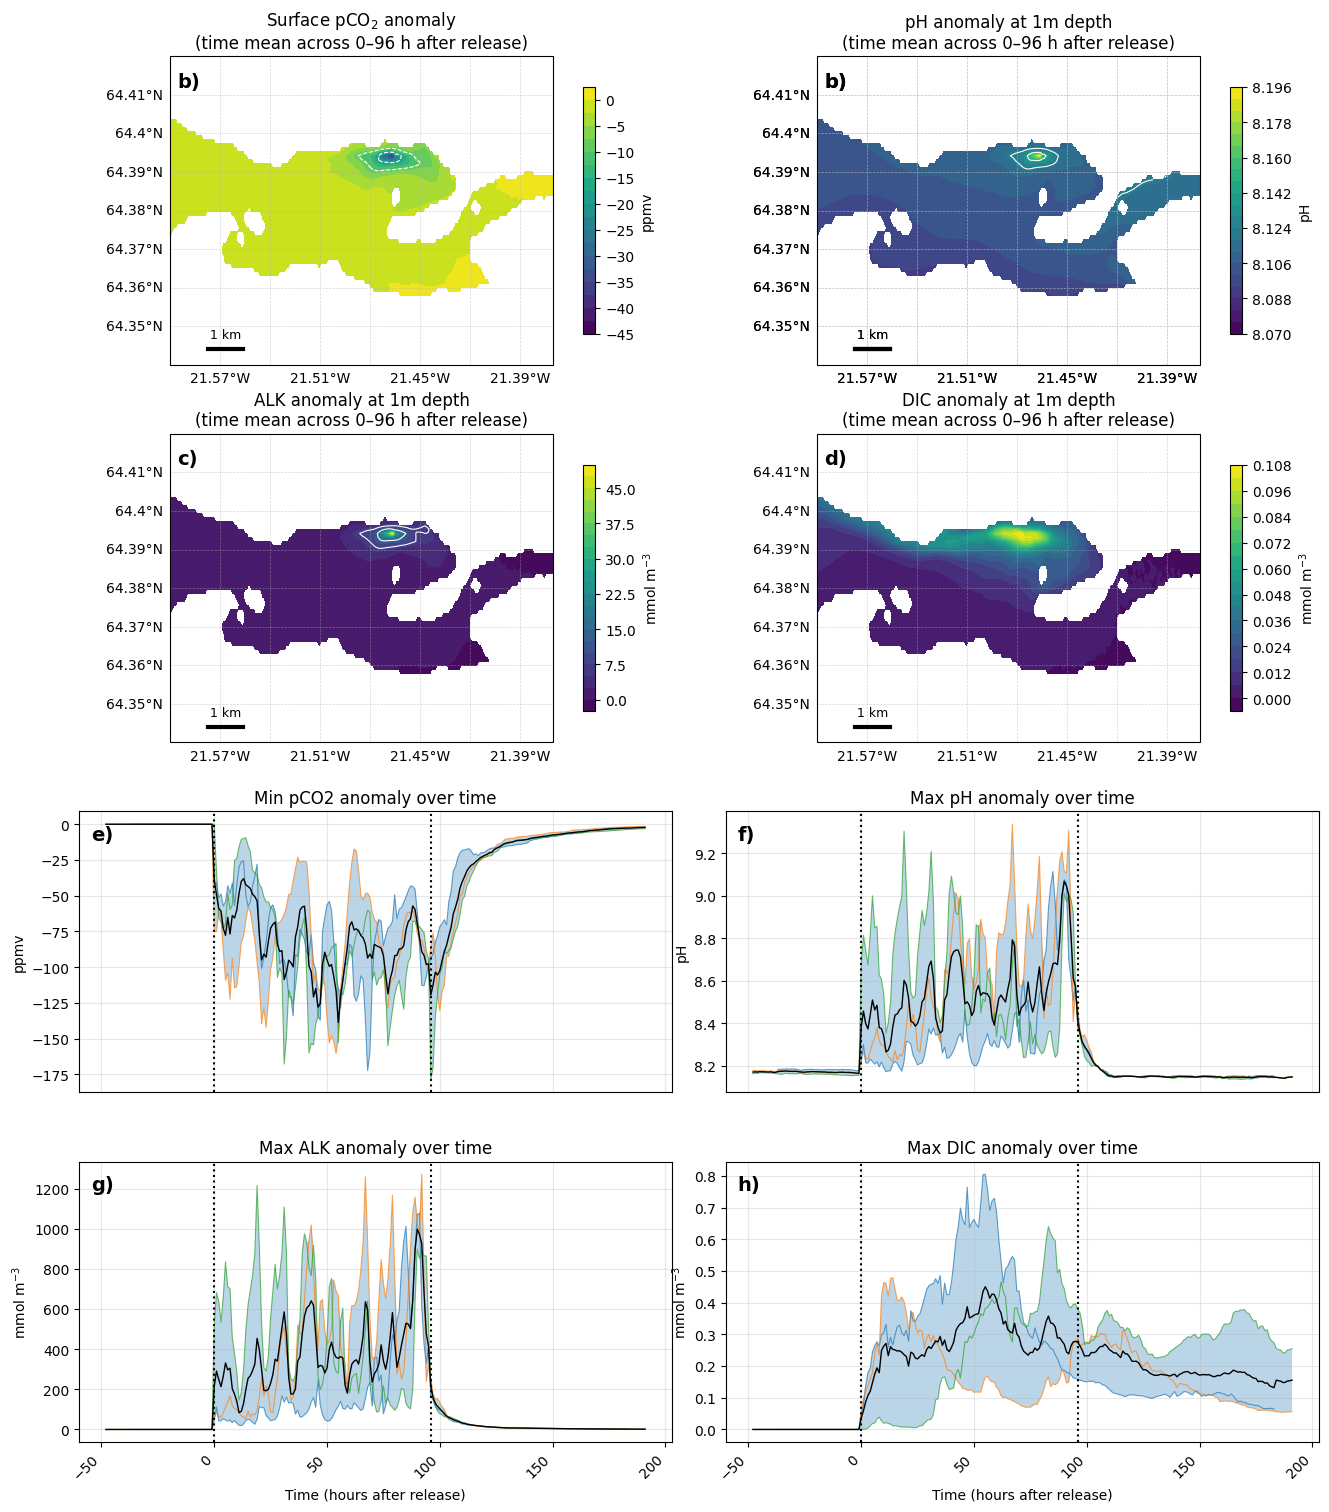

In [16]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

proj = ccrs.Mercator()


# ===============================
# Load NetCDF files
# ===============================

ds_pco2 = xr.open_dataset("Iceland3_pCO2SURF_1m_time0_96_mean.nc")
ds_ph   = xr.open_dataset("Iceland3_PH_1m_time0_96_mean.nc")
ds_alk  = xr.open_dataset("Iceland3_ALK_1m_time0_96_mean.nc")
ds_dic  = xr.open_dataset("Iceland3_DIC_1m_time0_96_mean.nc")

ds_metrics = xr.open_dataset("Iceland3_CDR_extrema_metrics.nc")
# ===============================
# Extract variables
# ===============================

FG_snapshot = ds_pco2["__xarray_dataarray_variable__"]
pH_surface = ds_ph["pH_3D"]
ALK_anom_surface = ds_alk["__xarray_dataarray_variable__"]
DIC_anom_surface = ds_dic["__xarray_dataarray_variable__"]

FG_min = ds_metrics["min_pCO2SURF_anom"]
pH_max = ds_metrics["max_PH_anom"]
ALK_max = ds_metrics["max_ALK_anom"]
DIC_max = ds_metrics["max_DIC_anom"]

time_rel = ds_metrics.time_rel
time_rel = ds_metrics.time_rel

time_label = "time mean across 0–96 h after release"

# -------------------------------
# Hvalfjörður extent
# -------------------------------
lon_min, lon_max = -21.6, -21.37
lat_min, lat_max = 64.34, 64.42

# Convert if grid is 0–360
#if ds_bgc_dia_ens.lon.max() > 180:
lon_min = lon_min % 360
lon_max = lon_max % 360

# ===============================
# Layout (2x2 maps + 2x2 TS)
# ===============================
fig = plt.figure(figsize=(16, 18))

gs = fig.add_gridspec(
    nrows=6,
    ncols=4,
    height_ratios=[3.5, 3.5, 1.2, 1.2, 1.2, 1.2],
    hspace=0.4
)

ax_c1 = fig.add_subplot(gs[0, 0:2], projection=proj)
ax_c2 = fig.add_subplot(gs[0, 2:4], projection=proj)
ax_c3 = fig.add_subplot(gs[1, 0:2], projection=proj)
ax_c4 = fig.add_subplot(gs[1, 2:4], projection=proj)

ax_ts1 = fig.add_subplot(gs[2:4, 0:2])
ax_ts2 = fig.add_subplot(gs[2:4, 2:4])
ax_ts3 = fig.add_subplot(gs[4:6, 0:2])
ax_ts4 = fig.add_subplot(gs[4:6, 2:4])

panel_labels = ["a)", "b)", "c)", "d)", "e)", "f)", "g)", "h)"]

def plot_map(ax, data, title, panel_label,stipple_level=None):

    ax.set_extent(
        [lon_min, lon_max, lat_min, lat_max],
        crs=ccrs.PlateCarree()
    )

    mean_field = data.mean("ens")
    std_field = data.std("ens")

    # -----------------------------
    # filled map
    # -----------------------------
    cf = ax.contourf(
        data.lon,
        data.lat,
        mean_field,
        levels=20,
        transform=ccrs.PlateCarree()
    )
    
    # -----------------------------
    # stippled contour
    # -----------------------------
    if stipple_level is not None:
        ax.contour(
            data.lon,
            data.lat,
            mean_field,
            levels=[stipple_level],
            colors="white",
            linewidths=0.8,
            hatches=["-"],
            transform=ccrs.PlateCarree()
        )
        ax.contour(
            data.lon,
            data.lat,
            mean_field,
            levels=[stipple_level*2],
            colors="white",
            linewidths=0.8,
            hatches=["-"],
            transform=ccrs.PlateCarree()
        )

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        linestyle="--",
        alpha=0.5
    )

    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(title)

    ax.text(
        0.02,
        0.95,
        panel_label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top"
    )

    add_scalebar(ax, 1)

    return cf
# ===============================
# Map plots
# ===============================

cf1 = plot_map(
    ax_c1,
    FG_snapshot,
    f"Surface pCO$_2$ anomaly\n({time_label})",
    panel_labels[1],
    stipple_level=-9.6   # pCO2
)

cf2 = plot_map(
    ax_c2,
    pH_surface,
    f"pH anomaly at 1m depth\n({time_label})",
    panel_labels[1],
    stipple_level=8.11  # pH
)

cf2 = plot_map(
    ax_c2,
    pH_surface,
    f"pH anomaly at 1m depth\n({time_label})",
    panel_labels[1],
    stipple_level=8.136# pH
)


cf3 = plot_map(
    ax_c3,
    ALK_anom_surface,
    f"ALK anomaly at 1m depth\n({time_label})",
    panel_labels[2],
    stipple_level=6.5   # ALK
)

cf4 = plot_map(
    ax_c4,
    DIC_anom_surface,
    f"DIC anomaly at 1m depth\n({time_label})",
    panel_labels[3],
    stipple_level=None  # no detectability contour
)

cb1 = fig.colorbar(cf1, ax=ax_c1, shrink=0.8)
cb1.set_label("ppmv")

cb2 = fig.colorbar(cf2, ax=ax_c2, shrink=0.8)
cb2.set_label("pH")

cb3 = fig.colorbar(cf3, ax=ax_c3, shrink=0.8)
cb3.set_label("mmol m$^{-3}$")

cb4 = fig.colorbar(cf4, ax=ax_c4, shrink=0.8)
cb4.set_label("mmol m$^{-3}$")

# ===============================
# Time series
# ===============================

ts_axes = [ax_ts1, ax_ts2, ax_ts3, ax_ts4]

ts_data = [
    (time_rel, FG_min, "Min pCO2 anomaly", "ppmv"),
    (time_rel, pH_max, "Max pH anomaly", "pH"),
    (time_rel, ALK_max, "Max ALK anomaly", "mmol m$^{-3}$"),
    (time_rel, DIC_max, "Max DIC anomaly", "mmol m$^{-3}$")
]

for i, ax in enumerate(ts_axes):

    t, data, ylabel, units = ts_data[i]

    y_min = data.min("ens")
    y_max = data.max("ens")
    y_mean = data.mean("ens")

    # -----------------------
    # thin ensemble members
    # -----------------------
    for ens in data.ens.values:
        ax.plot(
            t,
            data.sel(ens=ens),
            linewidth=0.8,
            alpha=0.7
        )

    # -----------------------
    # ensemble spread
    # -----------------------
    ax.fill_between(
        t,
        y_min,
        y_max,
        alpha=0.3
    )

    # -----------------------
    # ensemble mean
    # -----------------------
    ax.plot(
        t,
        y_mean,
        color="black",
        linewidth=1
    )

    ax.set_ylabel(units)
    ax.set_title(f"{ylabel} over time")

    ax.axvline(0, linestyle=":", linewidth=1.5, color="black")
    ax.axvline(96, linestyle=":", linewidth=1.5, color="black")

    ax.grid(True, alpha=0.3)

    ax.text(
        0.02,
        0.95,
        panel_labels[i+4],
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top"
    )

    for tick in ax.get_xticklabels():
        tick.set_rotation(45)
        tick.set_horizontalalignment("right")

    if i in [0, 1]:
        ax.set_xticklabels([])
        ax.tick_params(axis="x", which="both", length=0)
        
# Add x-axis label for bottom row
ax_ts3.set_xlabel("Time (hours after release)")
ax_ts4.set_xlabel("Time (hours after release)")
plt.show()

In [ ]:
ALK_max

In [ ]:
FG_min

Plot sum of ALK over time
Slice alk anomly with depth


In [87]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import PyCO2SYS as pyco2

max_ALK = ALK_max.mean('ens')+2320 #maximum background alkalinity
# -------------------------------
# 1. Extract max ALK timeseries
# -------------------------------

time = ALK_max['time_rel']

# -------------------------------
# 2. Set background constants
# -------------------------------
BACKGROUND1 = dict(
    ALK = max_ALK+60,     # mmol/m3 
    DIC = 2160.0,     # mmol/m3
    PO4 = 0.3,        ## mmol/m3
    Si = 2,         # mmol/m3
    T = 10.0,
    P = 0,
    S = 33.75,
)

BACKGROUND2 = dict(
    ALK = max_ALK,     # mmol/m3
    DIC = 2110.0,     # mmol/m3
    PO4 = 0.8,        ## mmol/m3
    Si = 6.8,         # mmol/m3
    T = 11.5,
    P = 0,
    S = 33.75)

import pandas as pd

# -------------------------------
# Collect scenarios
# -------------------------------
scenarios = {"Scenario 1": BACKGROUND1, "Scenario 2": BACKGROUND2}

# -------------------------------
# Build summary table
# -------------------------------
summary_rows = []
for name, params in scenarios.items():
    row = {
        "Scenario": name,
        "ALK (mmol/m3)": params["ALK"].values if isinstance(params["ALK"], xr.DataArray) else params["ALK"],
        "DIC (mmol/m3)": params["DIC"],
        "PO4 (mmol/m3)": params["PO4"],
        "Si (mmol/m3)": params["Si"],
        "T (°C)": params["T"],
        "P (dbar)": params["P"],
        "S (psu)": params["S"]
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df)


     Scenario                                      ALK (mmol/m3)  \
0  Scenario 1  [2380.0, 2380.0, 2380.0, 2380.0, 2380.0, 2380....   
1  Scenario 2  [2320.0, 2320.0, 2320.0, 2320.0, 2320.0, 2320....   

   DIC (mmol/m3)  PO4 (mmol/m3)  Si (mmol/m3)  T (°C)  P (dbar)  S (psu)  
0         2160.0            0.3           2.0    10.0         0    33.75  
1         2110.0            0.8           6.8    11.5         0    33.75  


In [88]:
import numpy as np
import PyCO2SYS as pyco2

def get_csys_with_volumetric_inputs(DATA):
    # --------------------------------
    # 1. Extract values
    # --------------------------------
    alk_vol = np.atleast_1d(DATA["ALK"]).astype(float)
    dic_vol = np.atleast_1d(DATA["DIC"]).astype(float)
    po4_vol = np.atleast_1d(DATA["PO4"]).astype(float)
    si_vol  = np.atleast_1d(DATA["Si"]).astype(float)

    # --------------------------------
    # 2. Clean inputs
    # --------------------------------
    alk_vol[alk_vol < 0] = np.nan
    dic_vol[dic_vol < 0] = np.nan

    # --------------------------------
    # 3. Get density
    # --------------------------------
    temp_results = pyco2.sys(
        par1=alk_vol,
        par2=dic_vol,
        par1_type=1,
        par2_type=2,
        salinity=DATA["S"],
        temperature=DATA["T"],
        pressure=DATA["P"]
    )

    rho = temp_results.get("rho", temp_results.get("density"))

    if rho is None:
        print("Warning: Density not found, using approximate seawater density.")
        rho = 1.026

    # --------------------------------
    # 4. Convert mmol/m3 → µmol/kg
    # --------------------------------
    alk_grav = alk_vol / rho
    dic_grav = dic_vol / rho
    po4_grav = po4_vol / rho
    si_grav  = si_vol / rho

    # --------------------------------
    # 5. Final carbonate system
    # --------------------------------
    results = pyco2.sys(
        par1=alk_grav,
        par2=dic_grav,
        par1_type=1,
        par2_type=2,
        salinity=DATA["S"],
        temperature=DATA["T"],
        pressure=DATA["P"],
        total_phosphate=po4_grav,
        total_silicate=si_grav
    )

    return results


# --------------------------------
# Scenario 1
# --------------------------------
bg1 = get_csys_with_volumetric_inputs(BACKGROUND1)
pH_bg1 = bg1["pH_total"]


# --------------------------------
# Scenario 2
# --------------------------------
bg2 = get_csys_with_volumetric_inputs(BACKGROUND2)
pH_bg2 = bg2["pH_total"]


# --------------------------------
# Print statistics
# --------------------------------
print("\nBACKGROUND 1")
print(f"pH values: {len(pH_bg1)}")
print(f"Average pH: {np.nanmean(pH_bg1):.4f}")


print("\nBACKGROUND 2")
print(f"pH values: {len(pH_bg2)}")
print(f"Average pH: {np.nanmean(pH_bg2):.4f}")



BACKGROUND 1
pH values: 288
Average pH: 8.3331

BACKGROUND 2
pH values: 288
Average pH: 8.3003


In [89]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import PyCO2SYS as pyco2
import pandas as pd

# --------------------------------
# Load max surface alkalinity file
# --------------------------------
ds_max_surface = xr.open_dataset("Iceland3_max_surface_alk.nc")

# surface alkalinity anomaly timeseries
max_ALK_surface = ds_max_surface["max_ALK_surface_anom"]

# ensemble mean and add background
max_ALK_surface_mean = max_ALK_surface.mean("ens") + 2320

# time coordinate
time = max_ALK_surface_mean["time_rel"]

# --------------------------------
# Background states
# --------------------------------
BACKGROUND1 = dict(
    ALK=max_ALK_surface_mean + 60,   # mmol/m3
    DIC=2160.0,
    PO4=0.3,
    Si=2,
    T=10.0,
    P=0,
    S=33.75,
)

BACKGROUND2 = dict(
    ALK=max_ALK_surface_mean,        # mmol/m3
    DIC=2110.0,
    PO4=0.8,
    Si=6.8,
    T=11.5,
    P=0,
    S=33.75,
)

# --------------------------------
# Collect scenarios
# --------------------------------
scenarios = {
    "Scenario 1": BACKGROUND1,
    "Scenario 2": BACKGROUND2
}

# --------------------------------
# Build summary table
# --------------------------------
summary_rows = []

for name, params in scenarios.items():

    alk_value = (
        float(params["ALK"].mean().values)
        if isinstance(params["ALK"], xr.DataArray)
        else params["ALK"]
    )

    row = {
        "Scenario": name,
        "ALK (mmol/m3)": alk_value,
        "DIC (mmol/m3)": params["DIC"],
        "PO4 (mmol/m3)": params["PO4"],
        "Si (mmol/m3)": params["Si"],
        "T (°C)": params["T"],
        "P (dbar)": params["P"],
        "S (psu)": params["S"]
    }

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

print(summary_df)

     Scenario  ALK (mmol/m3)  DIC (mmol/m3)  PO4 (mmol/m3)  Si (mmol/m3)  \
0  Scenario 1    2421.237599         2160.0            0.3           2.0   
1  Scenario 2    2361.237599         2110.0            0.8           6.8   

   T (°C)  P (dbar)  S (psu)  
0    10.0         0    33.75  
1    11.5         0    33.75  


In [90]:
import numpy as np
import PyCO2SYS as pyco2

def get_csys_with_volumetric_inputs(DATA):
    # --------------------------------
    # 1. Extract values
    # --------------------------------
    alk_vol = np.atleast_1d(DATA["ALK"]).astype(float)
    dic_vol = np.atleast_1d(DATA["DIC"]).astype(float)
    po4_vol = np.atleast_1d(DATA["PO4"]).astype(float)
    si_vol  = np.atleast_1d(DATA["Si"]).astype(float)

    # --------------------------------
    # 2. Clean inputs
    # --------------------------------
    alk_vol[alk_vol < 0] = np.nan
    dic_vol[dic_vol < 0] = np.nan

    # --------------------------------
    # 3. Get density
    # --------------------------------
    temp_results = pyco2.sys(
        par1=alk_vol,
        par2=dic_vol,
        par1_type=1,
        par2_type=2,
        salinity=DATA["S"],
        temperature=DATA["T"],
        pressure=DATA["P"]
    )

    rho = temp_results.get("rho", temp_results.get("density"))

    if rho is None:
        print("Warning: Density not found, using approximate seawater density.")
        rho = 1.026

    # --------------------------------
    # 4. Convert mmol/m3 → µmol/kg
    # --------------------------------
    alk_grav = alk_vol / rho
    dic_grav = dic_vol / rho
    po4_grav = po4_vol / rho
    si_grav  = si_vol / rho

    # --------------------------------
    # 5. Final carbonate system
    # --------------------------------
    results = pyco2.sys(
        par1=alk_grav,
        par2=dic_grav,
        par1_type=1,
        par2_type=2,
        salinity=DATA["S"],
        temperature=DATA["T"],
        pressure=DATA["P"],
        total_phosphate=po4_grav,
        total_silicate=si_grav
    )

    return results


# --------------------------------
# Scenario 1
# --------------------------------
bg1 = get_csys_with_volumetric_inputs(BACKGROUND1)
pCO2_bg1 = bg1["pCO2"]

# --------------------------------
# Scenario 2
# --------------------------------
bg2 = get_csys_with_volumetric_inputs(BACKGROUND2)
pCO2_bg2 = bg2["pCO2"]

# --------------------------------
# Print statistics
# --------------------------------
print("\nBACKGROUND 1")

print(f"Average pCO2: {np.nanmean(pCO2_bg1):.2f} µatm")

print("\nBACKGROUND 2")

print(f"Average pCO2: {np.nanmean(pCO2_bg2):.2f} µatm")


BACKGROUND 1
Average pCO2: 278.51 µatm

BACKGROUND 2
Average pCO2: 299.38 µatm


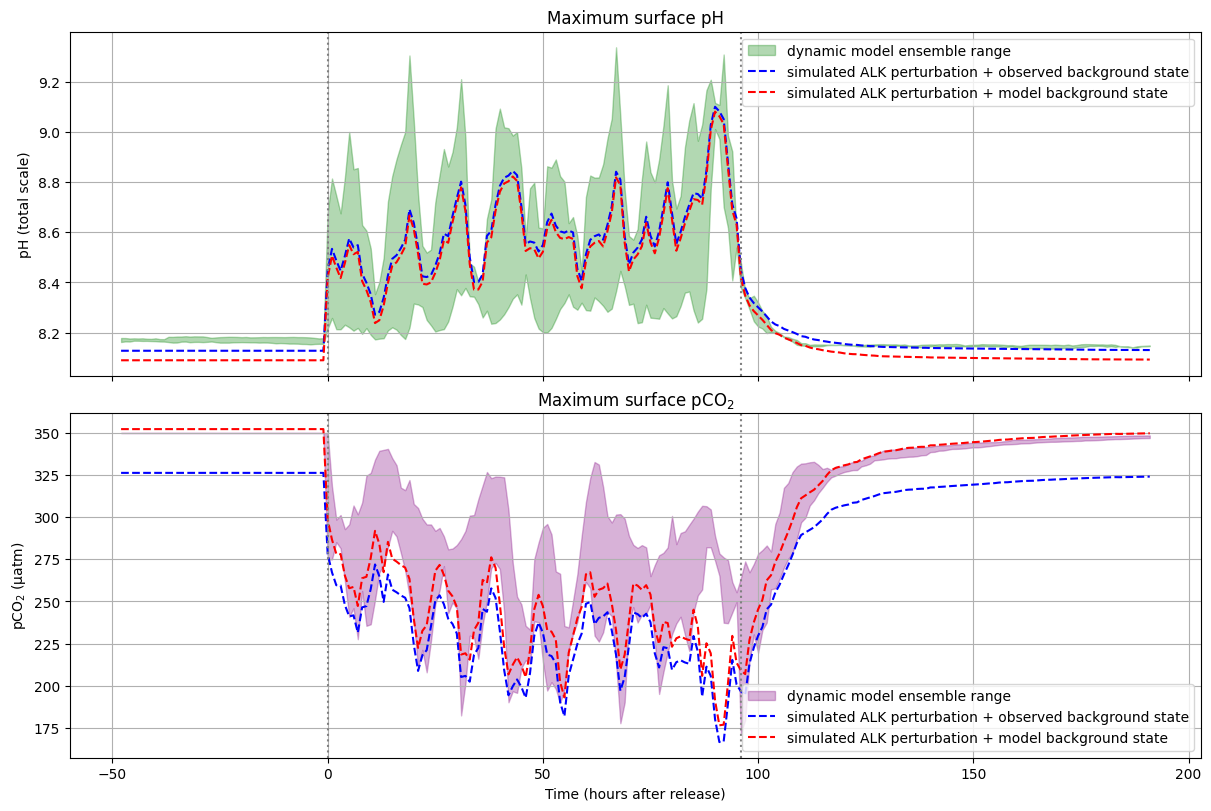

In [94]:
import matplotlib.pyplot as plt
import xarray as xr

# --------------------------------
# Load max surface pCO2 file
# --------------------------------
ds_pco2 = xr.open_dataset("Iceland3_max_surface_pCO2.nc")

pCO2_max = FG_min+350

# ensure same time axis
time = pCO2_max.time_rel

# --------------------------------
# pH ensemble spread
# --------------------------------
time_pH = pH_max.time_rel

pH_min = pH_max.min(dim="ens")
pH_max_env = pH_max.max(dim="ens")
pH_mean = pH_max.mean(dim="ens")

# --------------------------------
# pCO2 ensemble spread (from file)
# --------------------------------
pCO2_min_env = pCO2_max.min(dim="ens")
pCO2_max_env = pCO2_max.max(dim="ens")
pCO2_mean = pCO2_max.mean(dim="ens")

# --------------------------------
# Figure
# --------------------------------
fig, axs = plt.subplots(
    2, 1,
    figsize=(12,8),
    sharex=True,
    constrained_layout=True
)

# =====================================================
# Panel 1: Maximum pH
# =====================================================
axs[0].fill_between(
    time_pH,
    pH_min,
    pH_max_env,
    color='green',
    alpha=0.3,
    label='dynamic model ensemble range'
)

#axs[0].plot(
#    time_pH,
#    pH_mean,
#    color='green',
#    linewidth=2,
#    label='dynamic model ensemble mean'
#)

axs[0].plot(
    time_pH,
    pH_bg1,
    linestyle='--',
    color='blue',
    label='simulated ALK perturbation + observed background state'
)

axs[0].plot(
    time_pH,
    pH_bg2,
    linestyle='--',
    color='red',
    label='simulated ALK perturbation + model background state'
)

axs[0].set_ylabel("pH (total scale)")
axs[0].set_title("Maximum surface pH")
axs[0].grid(True)
axs[0].legend()

# =====================================================
# Panel 2: Minimum pCO2
# =====================================================
axs[1].fill_between(
    time,
    pCO2_min_env,
    pCO2_max_env,
    color='purple',
    alpha=0.3,
    label='dynamic model ensemble range'
)

#axs[1].plot(
#    time,
#    pCO2_mean,
#    color='purple',
#    linewidth=2,
#    label='dynamic model ensemble mean'
#)

axs[1].plot(
    time,
    pCO2_bg1,
    linestyle='--',
    color='blue',
    label='simulated ALK perturbation + observed background state'
)

axs[1].plot(
    time,
    pCO2_bg2,
    linestyle='--',
    color='red',
    label='simulated ALK perturbation + model background state'
)

axs[1].set_ylabel("pCO$_2$ (µatm)")
axs[1].set_xlabel("Time (hours after release)")
axs[1].set_title("Maximum surface pCO$_2$")
axs[1].grid(True)
axs[1].legend()

# --------------------------------
# Release window
# --------------------------------
for ax in axs:
    ax.axvline(0, linestyle=":", color="grey")
    ax.axvline(96, linestyle=":", color="grey")

plt.show()

In [ ]:
DIC_vert_int = (DIC_anom * dz_da).sum(dim="depth")
DIC_cum = (DIC_vert_int.isel(time=-1)).load()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec

lon_min, lon_max = -21.6, -21.37
lat_min, lat_max = 64.34, 64.42

# =========================
# --- LOAD CDR METRICS ---
# =========================
ensemble_ids = ["CDR1", "CDR2", "CDR3", "CDR4", "CDR5", "CDR6"]

cdr_paths = {
    ens: f"Iceland3_{ens}_cdr_metrics.nc"
    for ens in ensemble_ids
}

cdr_datasets = {ens: xr.open_dataset(path) for ens, path in cdr_paths.items()}

eff_rel_list = []

for ens in ensemble_ids:

    ds = cdr_datasets[ens]
    eff = ds["cdr_efficiency"]

    first_valid_index = np.where(np.isfinite(eff.values))[0][0]

    time_rel = np.arange(len(eff)) - first_valid_index

    eff_rel = eff.assign_coords(time_rel=("time", time_rel))
    eff_rel = eff_rel.swap_dims({"time": "time_rel"})
    eff_rel = eff_rel.drop_vars("time")

    eff_rel_list.append(eff_rel)

common_time_rel = np.arange(
    max(e.time_rel.min().item() for e in eff_rel_list),
    min(e.time_rel.max().item() for e in eff_rel_list) + 1
)

eff_aligned = [e.sel(time_rel=common_time_rel) for e in eff_rel_list]

eff_stack = xr.concat(eff_aligned, dim="ens")
eff_stack["ens"] = ensemble_ids

eff_mean = eff_stack.mean("ens", skipna=True)
eff_min = eff_stack.min("ens", skipna=True)
eff_max = eff_stack.max("ens", skipna=True)

time_rel = eff_mean.time_rel


# =========================
# --- LOAD NEW CSTAR FILES ---
# =========================
cstar_paths = {
    ens: f"ds_cstar{i}_regridded.nc"
    for i, ens in enumerate(ensemble_ids, start=1)
}

cstar_datasets = {ens: xr.open_dataset(path) for ens, path in cstar_paths.items()}

fg_list = []
dic_list = []

for ens in ensemble_ids:

    ds = cstar_datasets[ens]

    # --- FG cumulative anomaly ---
    FG = ds["FG_CO2"]-ds["FG_ALT_CO2"]
    FG_anom = FG
    FG_cumsum = FG_anom.cumsum("time")

    # --- DIC cumulative anomaly ---
    DIC = ds["hDIC_sum"]-ds["hDIC_ALT_CO2_sum"]
    DIC_anom = DIC
    DIC_cumsum = DIC_anom
    DIC_int = DIC_cumsum

    fg_list.append(FG_cumsum)
    dic_list.append(DIC_int)


# =========================
# --- ENSEMBLE MEAN MAPS ---
# =========================
FG_stack = xr.concat(fg_list, dim="ens")
DIC_stack = xr.concat(dic_list, dim="ens")

FG_mean = FG_stack.mean("ens").isel(time=-1)
DIC_mean = DIC_stack.mean("ens").isel(time=-1)

lon = FG_mean["lon"]
lat = FG_mean["lat"]

land_mask = (FG_mean == 0)

# =========================
# --- FIGURE LAYOUT ---
# =========================
fig = plt.figure(figsize=(12, 10))

gs = gridspec.GridSpec(
    nrows=2,
    ncols=2,
    height_ratios=[2.2, 1],
    hspace=0.12,   # reduced from 0.25
    wspace=0.15
)

proj = ccrs.Mercator()
pc = ccrs.PlateCarree()

def plot_map(ax, data, title, label, letter, show_lat_labels=True):

    ax.set_title(title, fontsize=12)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=pc)

    ax.contourf(
        lon,
        lat,
        land_mask,
        levels=[0.5, 1.5],
        colors=["lightgrey"],
        transform=pc,
        zorder=2
    )

    im = ax.pcolormesh(
        lon,
        lat,
        data,
        transform=pc,
        shading="auto",
        zorder=1
    )

    gl = ax.gridlines(
        crs=pc,
        draw_labels=True,
        linewidth=0.5,
        linestyle="--",
        alpha=0.5
    )

    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = show_lat_labels   # <-- control latitude labels
    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}

    cb = plt.colorbar(im, ax=ax, shrink=0.6)
    cb.set_label(label)

    ax.text(
        -0.05,
        1.05,
        letter,
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='right'
    )

# =========================
# --- FG_CO2 MAP ---
# =========================
ax_map1 = fig.add_subplot(gs[0, 0], projection=proj)

plot_map(
    ax_map1,
    FG_mean,
    "Cumulative FG$_{CO2}$ anomaly\n(ensemble mean)",
    "mmol m$^{-2}$",
    "a)"
)


# =========================
# --- DIC MAP ---
# =========================
ax_map2 = fig.add_subplot(gs[0, 1], projection=proj)

plot_map(
    ax_map2,
    DIC_mean,
    "Depth-integrated DIC anomaly\n(ensemble mean)",
    "mmol m$^{-2}$",
    "b)",
    show_lat_labels=False
)
# =========================
# --- TIME SERIES ---
# =========================
ax_ts = fig.add_subplot(gs[1, :])

# --- ensemble spread ---
ax_ts.fill_between(
    time_rel,
    eff_min.values,
    eff_max.values,
    alpha=0.3,
    label="Ensemble spread"
)

# --- individual ensemble members (thin lines) ---
for ens in eff_stack.ens.values:
    ax_ts.plot(
        time_rel,
        eff_stack.sel(ens=ens).values,
        linewidth=1,
        alpha=0.7,
        linestyle="-",
        label=f"{ens}"
    )

# --- ensemble mean ---
ax_ts.plot(
    time_rel,
    eff_mean.values,
    linewidth=2.5,
    color="black",
    label="Ensemble mean"
)

# --- red stippled vertical lines at 0 and 96 hrs ---
for t in [0, 96]:
    ax_ts.axvline(
        x=t,
        color="red",
        linestyle=":",
        linewidth=2
    )

ax_ts.set_title("CDR efficiency (∑DIC / ∑ALK)")
ax_ts.set_xlabel("Time (hours after release)")
ax_ts.set_ylabel("Efficiency")

ax_ts.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

# cleaner legend
ax_ts.legend(ncol=4, frameon=False)

ax_ts.text(
    -0.02,
    1.08,
    "c)",
    transform=ax_ts.transAxes,
    fontsize=16,
    fontweight='bold',
    va='top',
    ha='right'
)
plt.setp(ax_ts.get_xticklabels(), rotation=30, ha="right")

plt.subplots_adjust(top=0.95, bottom=0.08)

plt.show()

In [95]:
import numpy as np
import PyCO2SYS as pyco2

# ==========================================
# Baseline conditions
# ==========================================

ALK0 = 2300   # umol/kg
DIC0 = 2100   # umol/kg
T0   = 8      # degC
S0   = 34.5   # psu
PO4  = 0      # umol/kg
Si   = 0      # umol/kg
P    = 0      # dbar

# ==========================================
# Variability
# ==========================================

dALK = 15
dDIC = 50
dT   = 2
dS   = 0.25

# ==========================================
# Function to compute pCO2
# ==========================================

def compute_pco2(alk, dic, temp, salt):
    result = pyco2.sys(
        par1=alk,
        par2=dic,
        par1_type=1,   # ALK
        par2_type=2,   # DIC
        temperature=temp,
        salinity=salt,
        pressure=P,
        total_phosphate=PO4,
        total_silicate=Si,
        opt_k_carbonic=10,
        opt_k_bisulfate=1
    )
    return result["pCO2"]

# ==========================================
# Baseline pCO2
# ==========================================

pco2_base = compute_pco2(ALK0, DIC0, T0, S0)

# ==========================================
# Combined perturbation
# ==========================================

pco2_perturbed = compute_pco2(
    ALK0 + dALK,
    DIC0 + dDIC,
    T0 + dT,
    S0 + dS
)

delta_total = pco2_perturbed - pco2_base

# ==========================================
# Individual sensitivities
# ==========================================

pco2_alk = compute_pco2(ALK0 + dALK, DIC0, T0, S0)
pco2_dic = compute_pco2(ALK0, DIC0 + dDIC, T0, S0)
pco2_temp = compute_pco2(ALK0, DIC0, T0 + dT, S0)
pco2_salt = compute_pco2(ALK0, DIC0, T0, S0 + dS)

# ==========================================
# Print results
# ==========================================

print("Baseline pCO2:", float(pco2_base), "µatm")
print("Perturbed pCO2:", float(pco2_perturbed), "µatm")
print("Total ΔpCO2:", float(delta_total), "µatm")

print("\nIndividual contributions:")
print("ΔpCO2 from ALK:", float(pco2_alk - pco2_base), "µatm")
print("ΔpCO2 from DIC:", float(pco2_dic - pco2_base), "µatm")
print("ΔpCO2 from Temperature:", float(pco2_temp - pco2_base), "µatm")
print("ΔpCO2 from Salinity:", float(pco2_salt - pco2_base), "µatm")

Baseline pCO2: 325.6772720020019 µatm
Perturbed pCO2: 446.2754679002321 µatm
Total ΔpCO2: 120.59819589823019 µatm

Individual contributions:
ΔpCO2 from ALK: -23.223870131872218 µatm
ΔpCO2 from DIC: 117.3163866602668 µatm
ΔpCO2 from Temperature: 29.52740045193491 µatm
ΔpCO2 from Salinity: 2.148179977631685 µatm
